poem
{
    'topic': '猫咪',
    'poem': '## 
《猫说》\n\n我写着关于语言，\n关于夜晚的诗。\n我的一只陶碗里盛着另外的月亮；\n蜂蜜罐里，\n蜷着那个酷烈已逝的夏天。\
n我轻抚着语言——写作的痕迹，\n直到一句话绕着另一句：\n“让璎珞坐在稿纸上，\n镇压那些不规整的意象。”\n它便坐下了。',
    'ci_poem': '## 
《午后书桌》\n\n毛球蜷成灰白的绒团，\n在键盘左侧的暖光里轻眠。\n肉垫偶尔微颤，\n像在梦里拨动隐形的琴弦。\n\n窗台花
影里探出湿鼻头，\n追逐飞过文稿的碎光片。\n突然扑向旋转的银币，\n却在咫尺外凝成优雅的悬念。\n\n收起利爪的梅花印，\n
踩着纸页间的词句漫步。\n尾巴卷起晚风的金色符号，\n打翻了我刚泡好的茶烟。\n\n当月亮在墨砚里浮起，\n你跃上书脊如跃过
山脊。\n瞳孔里游着细碎的星群，\n喵叫声融化在笔尖的迟疑。',
    'content_type': '诗'
}

joke
{
    'topic': '猫咪',
    'ci_poem': '## 
《猫的禅意》\n\n他走来时\n日光悄悄游过椅子的边沿\n他的尾巴画出辽阔弧线\n茶梗在沸水中立起\n他绕过所有模糊的边界\n\n
每当走近\n总会有句呼噜凝在半空\n打翻尚未成形的名字\n某个午后\n他蹲在墨水瓶旁边\n把未干的句号\n舔成浑圆的光斑',
    'joke': 
'好的，这里有一个关于猫咪的笑话：\n\n**一个笑话：**\n\n一只猫走进了宠物用品店。店主热情地招呼它：“欢迎光临！您需要
点什么？”\n\n猫抬头看了看，用爪子指了指一盒高级猫罐头。\n\n店主微笑着说：“哦，您要这个？这可是最新口味，吞拿鱼配大
虾，很受欢迎的。”\n\n猫点了点头，示意要买。店主开了票，猫从容地从腰包里掏出一叠猫币付了账。\n\n店主找完零钱后，有些
好奇地问：“您是自己买东西吗？很少见到猫能自己赚钱的。您是怎么做到的？”\n\n猫叹了口气，无奈地说：\n\n“这年头，不掌握
两门外语，谁会给你买小鱼干？”',
    'content_type': '笑话'
}

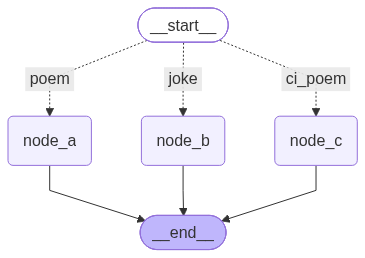

In [1]:
# add_conditional_edges
from typing import TypedDict, Literal, Sequence

from aiohttp.web_fileresponse import content_type
from langchain_classic.evaluation.parsing import json_schema
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from rich import print as rprint

load_dotenv(override=True)

model = ChatOpenAI(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": { "type": "disabled" }
    }
)
class OverALlState(TypedDict):
    topic: str
    poem: str
    ci_poem: str
    joke: str
    content_type: str

def node_a(state: OverALlState) -> dict:
    poem = model.invoke([f"写一首关于{state['topic']}的诗"]).content
    return {
        "poem": poem
    }

def node_c(state: OverALlState) -> dict:
    ci_poem = model.invoke([f"写一首关于{state['topic']}的诗"]).content
    return {
        "ci_poem": ci_poem
    }

def node_b(state: OverALlState) -> dict:
    joke = model.invoke([f"写一个关于{state['topic']}主题的笑话"]).content
    return {
        "joke": joke
    }

def route(state: OverALlState) -> Sequence[Literal["poem", "joke", "ci_poem"]]:
    if "诗" in state["content_type"]:
        return ["poem","ci_poem"]
    else:
        return ["joke","ci_poem"]

builder = StateGraph(state_schema=OverALlState)

builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_conditional_edges(START, route, path_map={
    "poem": "node_a",
    "joke": "node_b",
    "ci_poem": "node_c"
})
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)
builder.add_edge("node_c", END)

graph = builder.compile()

poem = graph.invoke({"topic": "猫咪", "content_type": "诗"})

joke = graph.invoke({"topic": "猫咪", "content_type": "笑话"})

rprint("poem", poem)
rprint("joke", joke)

from IPython.display import display
display(graph)




